# Customer Churn Analysis and Retention Strategy
**Author:** Sanman Kadam  
**Status:** Complete  
**License:** MIT  

---

## 1. Business Problem
A telecom company operating across major regional circles in India is experiencing customer attrition (churn), leading to substantial revenue loss and increased subscriber acquisition costs. In the highly competitive Indian telecom market, retaining high-value subscribers is critical for maintaining market share and profitability.

The objective of this project is to analyze historical subscriber data, identify key drivers of customer churn, segment regional circles based on risk and revenue value, and build machine learning models to predict subscriber decline at a circle level. These insights will drive action-oriented retention strategies with quantifiable business impact.

## 2. Project Objectives
- **Descriptive Analysis:** Understand subscriber trends and regional differences across circles.
- **Revenue Risk Mapping:** Quantify the financial impact of subscriber attrition across different regions and connection types.
- **Risk Segmentation:** Categorize circles into risk tiers (Low, Medium, High, Critical) using a composite risk score.
- **Predictive Modeling:** Train and evaluate classification models (Logistic Regression, Random Forest, Decision Trees, etc.) to predict subscriber decline.
- **Strategic Recommendations:** Propose specific, ROI-backed actions to minimize churn and protect revenue.

---


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
import os
paths = ["Telecom_Features.csv", "notebooks/Telecom_Features.csv", "../data/Telecom_Features.csv", "data/Telecom_Features.csv"]
for path in paths:
    if os.path.exists(path):
        df = pd.read_csv(path)
        break


In [13]:
df.head()

,year,month,circle,type_of_connection,service_provider,value,unit,notes,month_num,date,...,trend_12m,total_circle_subscribers,market_share,market_rank,share_gap_leader,relative_performance,circle_type,is_wireless,market_size_category,operator_geographic_diversity
0,2009,January,Andaman and Nicobar,wireless,BSNL,75011.0,value in absolute number,NaN,1,2009-01-01,...,75011.0,75011.0,1.0,1.0,0.0,1.0,Non-Metro,1.0,399688.0,27.0
1,2009,February,Andaman and Nicobar,wireless,BSNL,76058.0,value in absolute number,NaN,2,2009-02-01,...,76058.0,76058.0,1.0,1.0,0.0,1.0,Non-Metro,1.0,399688.0,27.0
2,2009,March,Andaman and Nicobar,wireless,BSNL,79682.0,value in absolute number,NaN,3,2009-03-01,...,79682.0,79682.0,1.0,1.0,0.0,1.0,Non-Metro,1.0,399688.0,27.0
3,2009,April,Andaman and Nicobar,wireless,BSNL,83332.0,value in absolute number,NaN,4,2009-04-01,...,83332.0,83332.0,1.0,1.0,0.0,1.0,Non-Metro,1.0,399688.0,27.0
4,2009,May,Andaman and Nicobar,wireless,BSNL,85605.0,value in absolute number,NaN,5,2009-05-01,...,85605.0,85605.0,1.0,1.0,0.0,1.0,Non-Metro,1.0,399688.0,27.0


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30196 entries, 0 to 30195
Data columns (total 29 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   year                           30196 non-null  int64  
 1   month                          30196 non-null  str    
 2   circle                         30196 non-null  str    
 3   type_of_connection             30196 non-null  str    
 4   service_provider               30196 non-null  str    
 5   value                          30196 non-null  float64
 6   unit                           30196 non-null  str    
 7   notes                          51 non-null     str    
 8   month_num                      30196 non-null  int64  
 9   date                           30196 non-null  str    
 10  subscribers_lag_1              30196 non-null  float64
 11  subscribers_lag_3              30196 non-null  float64
 12  subscribers_lag_6              30196 non-null  float64
 1

In [15]:
df.describe()

,year,value,month_num,subscribers_lag_1,subscribers_lag_3,subscribers_lag_6,subscribers_lag_12,mom_growth,yoy_growth,growth_volatility_3,...,growth_volatility_12,trend_12m,total_circle_subscribers,market_share,market_rank,share_gap_leader,relative_performance,is_wireless,market_size_category,operator_geographic_diversity
count,30196.000000,3.019600e+04,30196.000000,3.019600e+04,3.019600e+04,3.019600e+04,3.019600e+04,30196.000000,30196.000000,30196.000000,...,30196.000000,3.019600e+04,3.019600e+04,3.019600e+04,30196.000000,30196.000000,3.019600e+04,30196.0,3.019600e+04,30196.000000
mean,2015.480593,6.493663e+06,6.432905,6.409953e+06,6.244317e+06,6.001269e+06,5.527567e+06,1.255653,3.398349,2.251584,...,4.602555,9.660954e+05,4.513675e+07,1.434627e-01,4.364585,0.166772,1.000000e+00,1.0,6.371401e+10,22.271526
std,4.447793,7.660631e+06,3.472843,7.632118e+06,7.571179e+06,7.473192e+06,7.249455e+06,84.353914,134.967844,88.316544,...,105.047168,3.964139e+06,2.547342e+07,1.192371e-01,2.584907,0.117612,7.496205e-01,0.0,3.332855e+10,3.912509
min,2009.000000,1.000000e+00,1.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-0.999874,-0.999999,0.000000,...,0.000000,-2.621584e+08,7.501100e+04,1.054136e-08,1.000000,0.000000,5.270680e-08,1.0,3.996880e+05,1.000000
25%,2012.000000,1.321853e+06,3.000000,1.260023e+06,1.125823e+06,8.834405e+05,3.484770e+05,-0.004093,-0.034139,0.003730,...,0.008422,-3.960775e+04,2.503378e+07,4.805258e-02,2.000000,0.063632,3.619951e-01,1.0,3.740886e+10,22.000000
50%,2015.000000,4.163613e+06,6.000000,4.085831e+06,3.894102e+06,3.624222e+06,3.109753e+06,0.004939,0.013501,0.008808,...,0.016492,2.643105e+05,4.250746e+07,1.165194e-01,4.000000,0.173003,9.122844e-01,1.0,6.560603e+10,23.000000
75%,2019.000000,8.546766e+06,9.000000,8.457286e+06,8.302580e+06,7.990465e+06,7.437632e+06,0.019673,0.143479,0.023318,...,0.042615,1.149061e+06,6.491619e+07,2.137794e-01,6.000000,0.249910,1.552174e+00,1.0,8.620524e+10,23.000000
max,2025.000000,2.955508e+08,12.000000,2.955508e+08,2.955508e+08,2.955508e+08,2.955508e+08,10262.242857,12873.142857,7256.501514,...,7256.501514,2.699598e+08,3.637702e+08,1.000000e+00,16.000000,0.812464,4.166926e+00,1.0,1.166914e+11,27.000000


In [16]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Check top rows and data info
print(df.head())
print(df.info())

   year     month               circle type_of_connection service_provider  \
0  2009   January  Andaman and Nicobar           wireless             BSNL   
1  2009  February  Andaman and Nicobar           wireless             BSNL   
2  2009     March  Andaman and Nicobar           wireless             BSNL   
3  2009     April  Andaman and Nicobar           wireless             BSNL   
4  2009       May  Andaman and Nicobar           wireless             BSNL   

     value                      unit notes  month_num        date  ...  \
0  75011.0  value in absolute number   NaN          1  2009-01-01  ...   
1  76058.0  value in absolute number   NaN          2  2009-02-01  ...   
2  79682.0  value in absolute number   NaN          3  2009-03-01  ...   
3  83332.0  value in absolute number   NaN          4  2009-04-01  ...   
4  85605.0  value in absolute number   NaN          5  2009-05-01  ...   

   trend_12m  total_circle_subscribers  market_share  market_rank  \
0    75011.0     

In [17]:
# Numeric summary
numeric_cols = df.select_dtypes(include=np.number).columns
print(df[numeric_cols].describe().T)

# Count of missing values
print(df.isna().sum())

# Unique values in key categorical columns
print(df['service_provider'].nunique(), df['circle'].nunique())


                                 count          mean           std  \
year                           30196.0  2.015481e+03  4.447793e+00   
value                          30196.0  6.493663e+06  7.660631e+06   
month_num                      30196.0  6.432905e+00  3.472843e+00   
subscribers_lag_1              30196.0  6.409953e+06  7.632118e+06   
subscribers_lag_3              30196.0  6.244317e+06  7.571179e+06   
subscribers_lag_6              30196.0  6.001269e+06  7.473192e+06   
subscribers_lag_12             30196.0  5.527567e+06  7.249455e+06   
mom_growth                     30196.0  1.255653e+00  8.435391e+01   
yoy_growth                     30196.0  3.398349e+00  1.349678e+02   
growth_volatility_3            30196.0  2.251584e+00  8.831654e+01   
growth_volatility_6            30196.0  3.456484e+00  9.851973e+01   
growth_volatility_12           30196.0  4.602555e+00  1.050472e+02   
trend_12m                      30196.0  9.660954e+05  3.964139e+06   
total_circle_subscri

In [18]:
# Fill missing growth values with median (more realistic)
df['mom_growth'] = df['mom_growth'].fillna(df['mom_growth'].median())
df['yoy_growth'] = df['yoy_growth'].fillna(df['yoy_growth'].median())

In [19]:
# Check missing values
print("Missing values after cleaning:\n", df.isna().sum())

Missing values after cleaning:
 year                                 0
month                                0
circle                               0
type_of_connection                   0
service_provider                     0
value                                0
unit                                 0
notes                            30145
month_num                            0
date                                 0
subscribers_lag_1                    0
subscribers_lag_3                    0
subscribers_lag_6                    0
subscribers_lag_12                   0
mom_growth                           0
yoy_growth                           0
growth_volatility_3                  0
growth_volatility_6                  0
growth_volatility_12                 0
trend_12m                            0
total_circle_subscribers             0
market_share                         0
market_rank                          0
share_gap_leader                     0
relative_performance            

In [20]:
# -----------------------
# Numeric Summary
# -----------------------
numeric_cols = df.select_dtypes(include=np.number).columns
print("\nNumeric Summary:\n", df[numeric_cols].describe().T)


Numeric Summary:
                                  count          mean           std  \
year                           30196.0  2.015481e+03  4.447793e+00   
value                          30196.0  6.493663e+06  7.660631e+06   
month_num                      30196.0  6.432905e+00  3.472843e+00   
subscribers_lag_1              30196.0  6.409953e+06  7.632118e+06   
subscribers_lag_3              30196.0  6.244317e+06  7.571179e+06   
subscribers_lag_6              30196.0  6.001269e+06  7.473192e+06   
subscribers_lag_12             30196.0  5.527567e+06  7.249455e+06   
mom_growth                     30196.0  1.255653e+00  8.435391e+01   
yoy_growth                     30196.0  3.398349e+00  1.349678e+02   
growth_volatility_3            30196.0  2.251584e+00  8.831654e+01   
growth_volatility_6            30196.0  3.456484e+00  9.851973e+01   
growth_volatility_12           30196.0  4.602555e+00  1.050472e+02   
trend_12m                      30196.0  9.660954e+05  3.964139e+06   
t

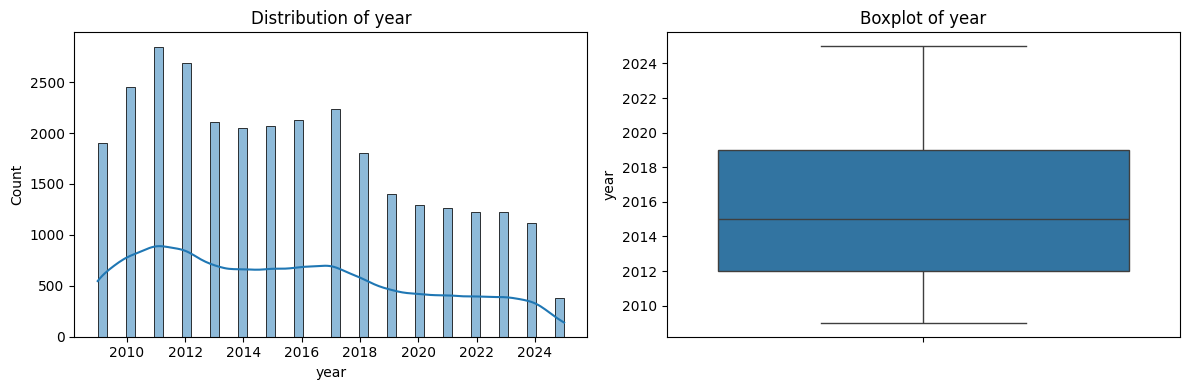

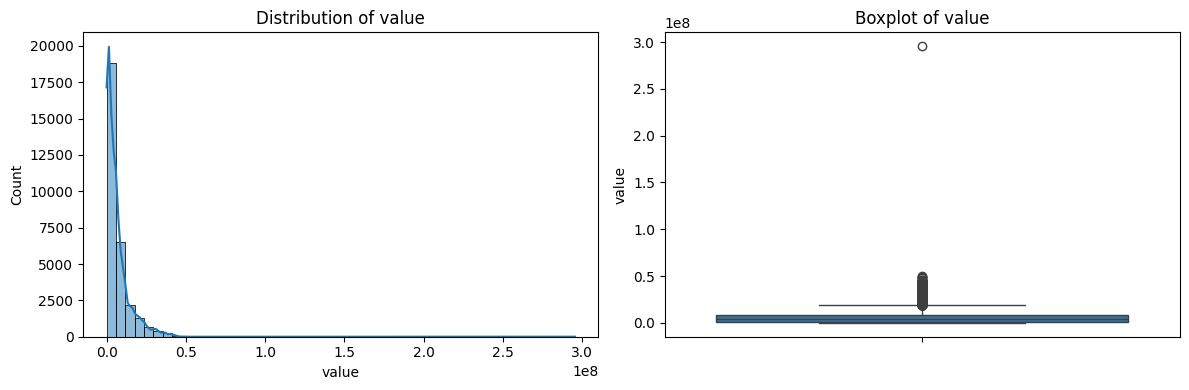

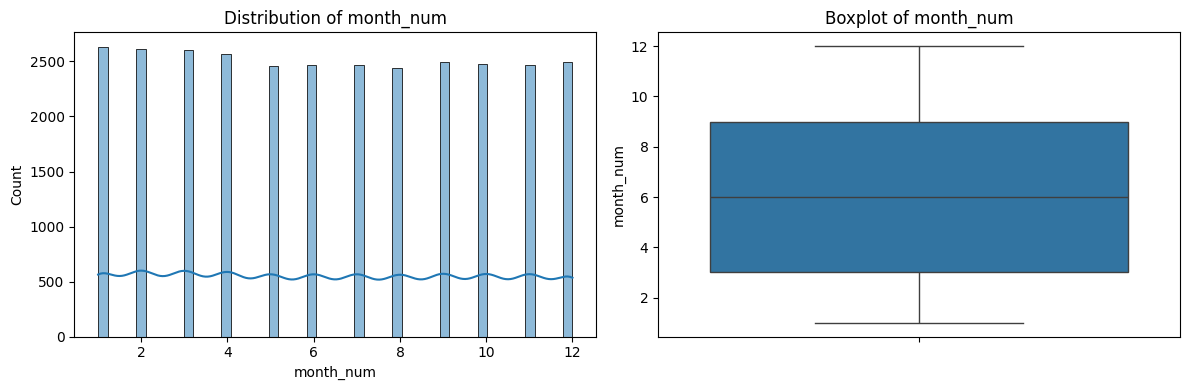

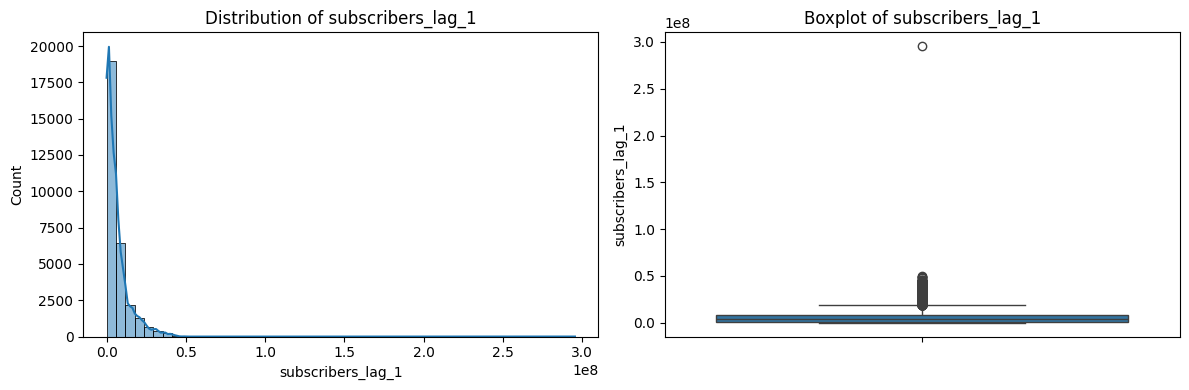

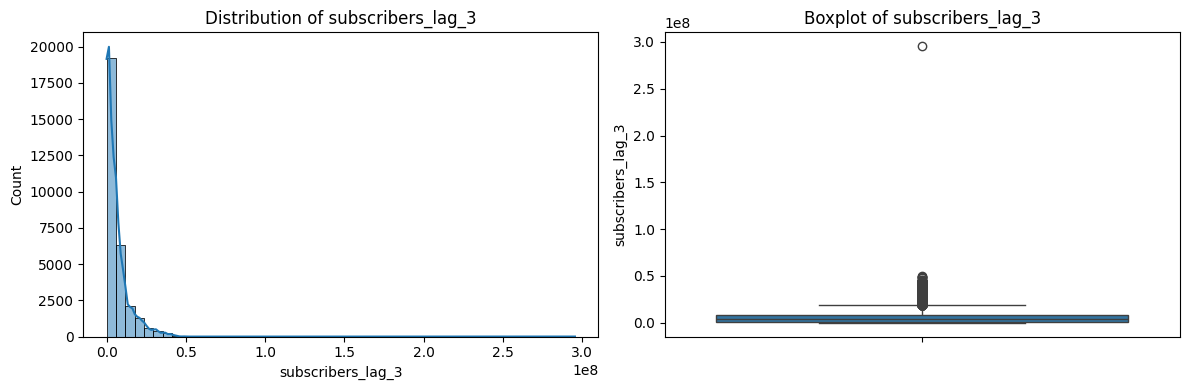

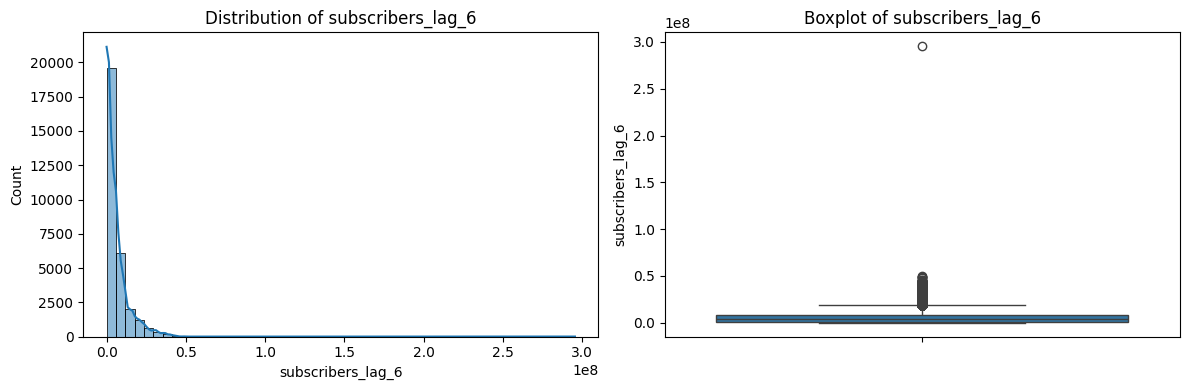

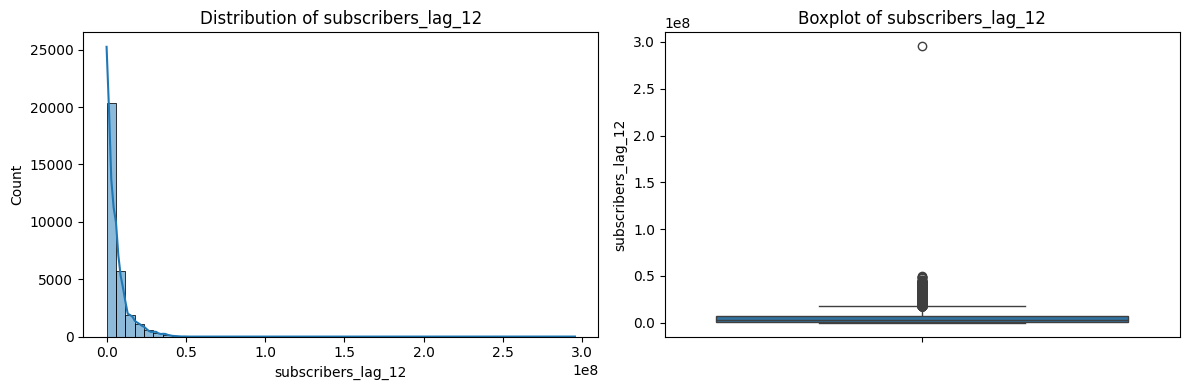

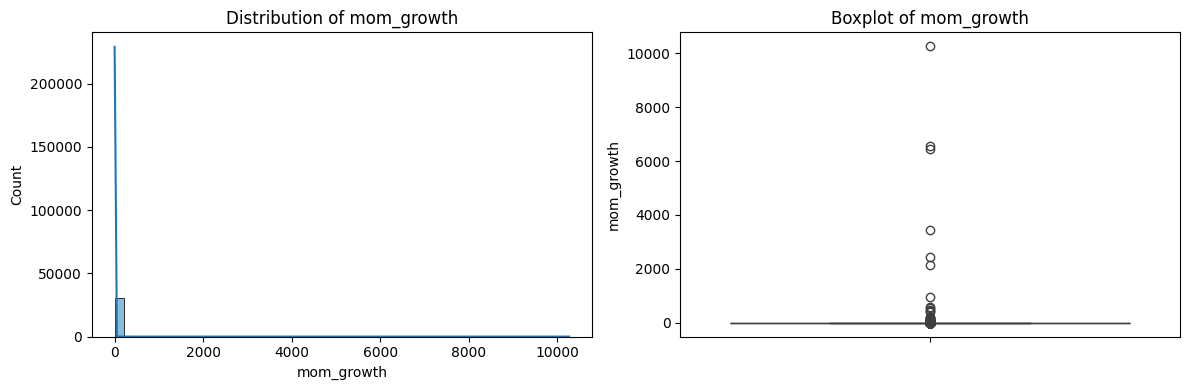

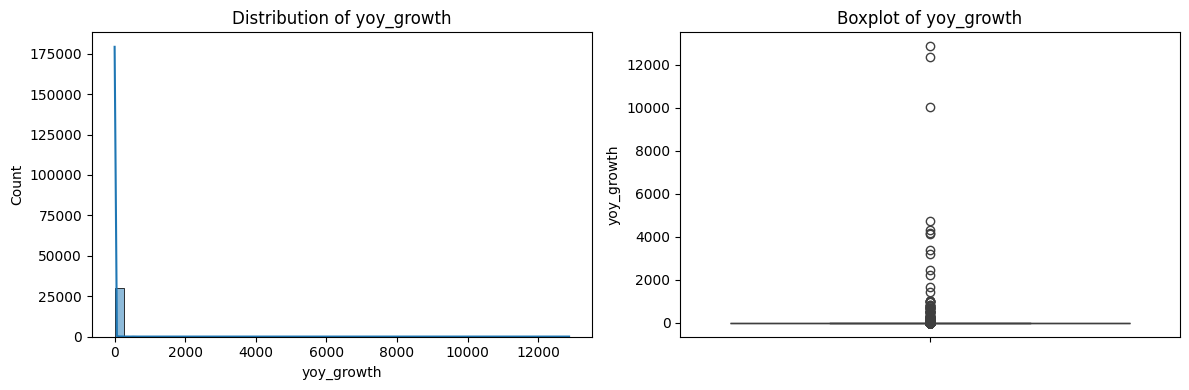

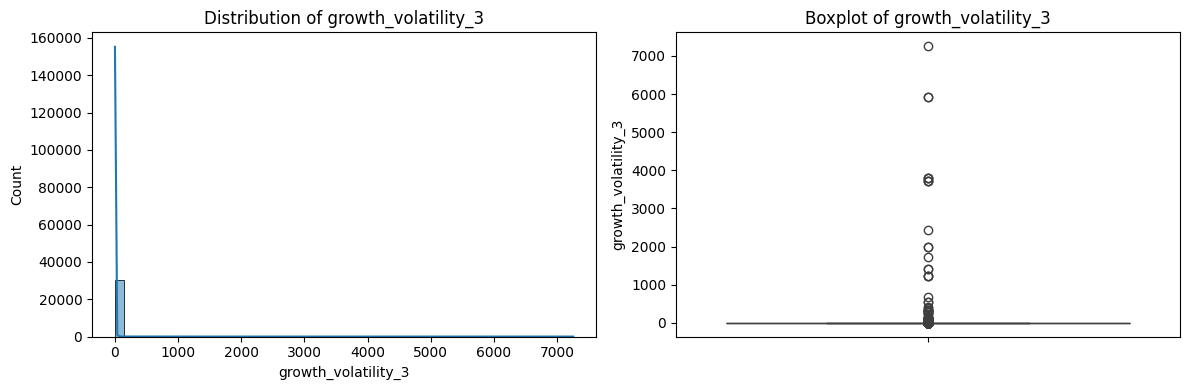

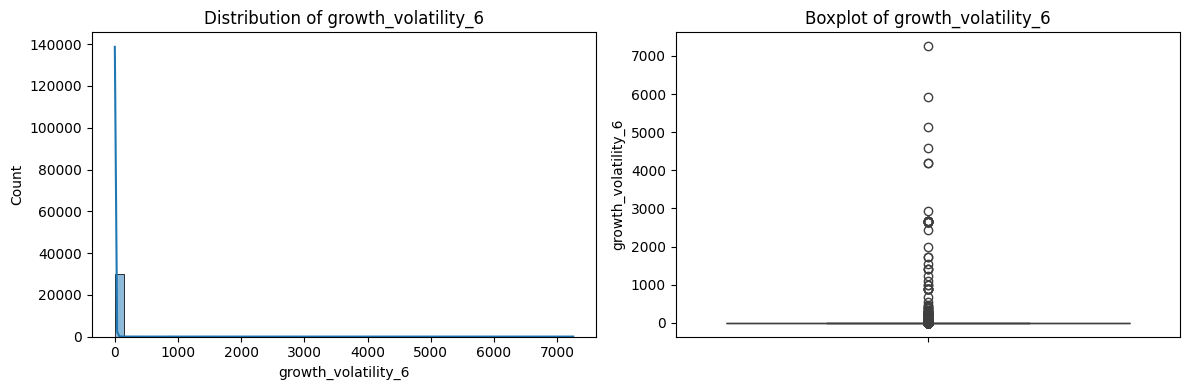

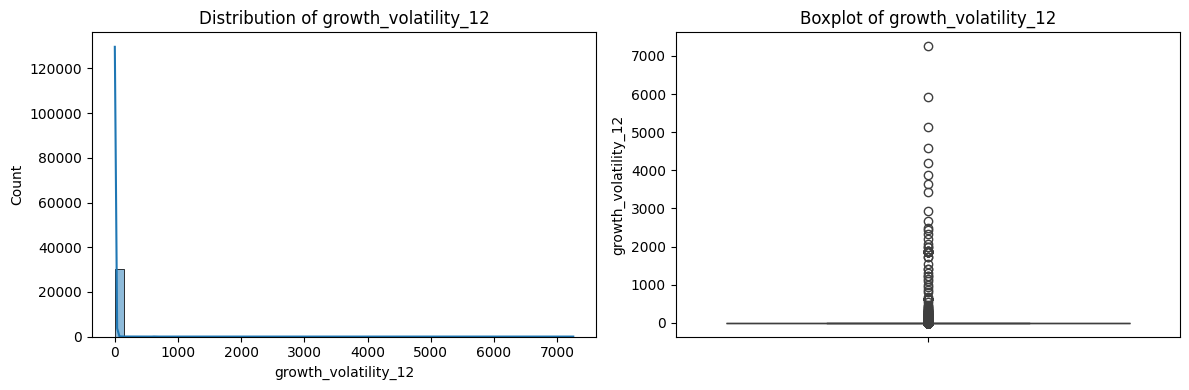

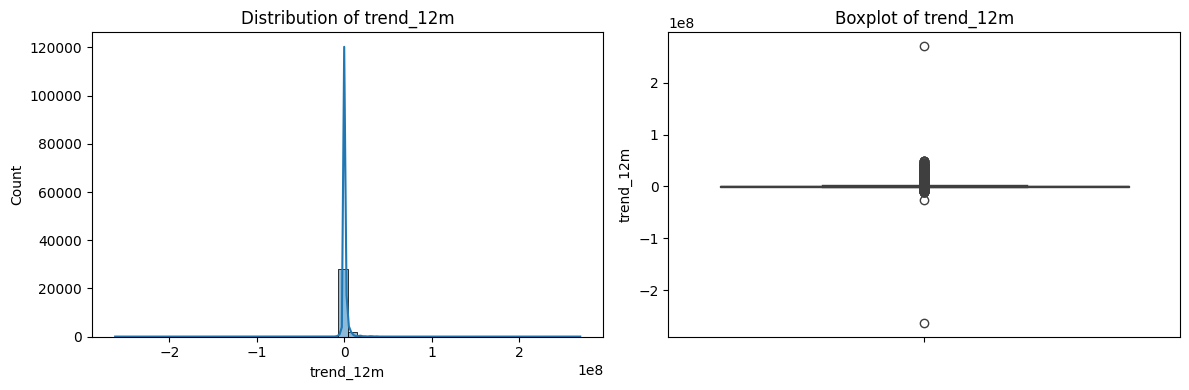

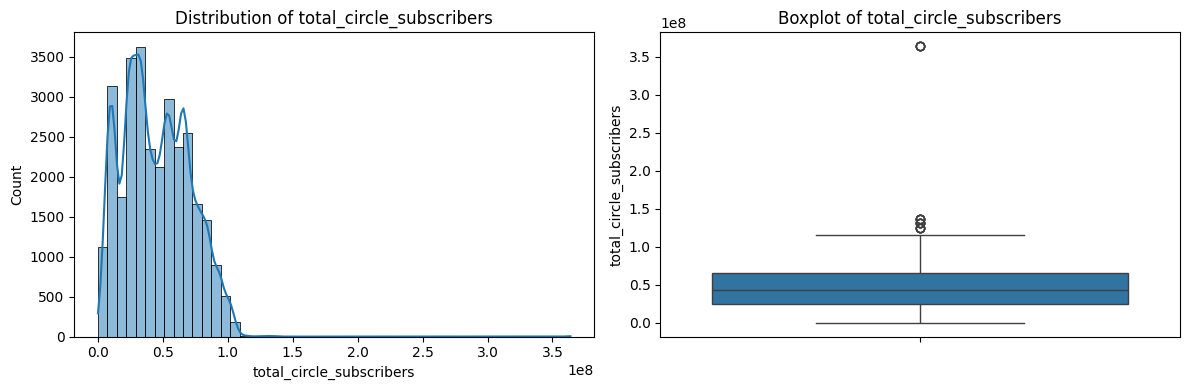

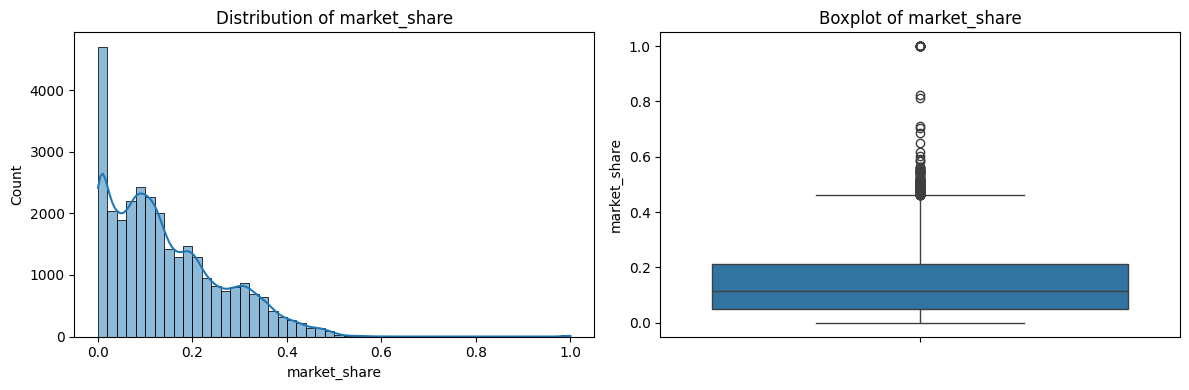

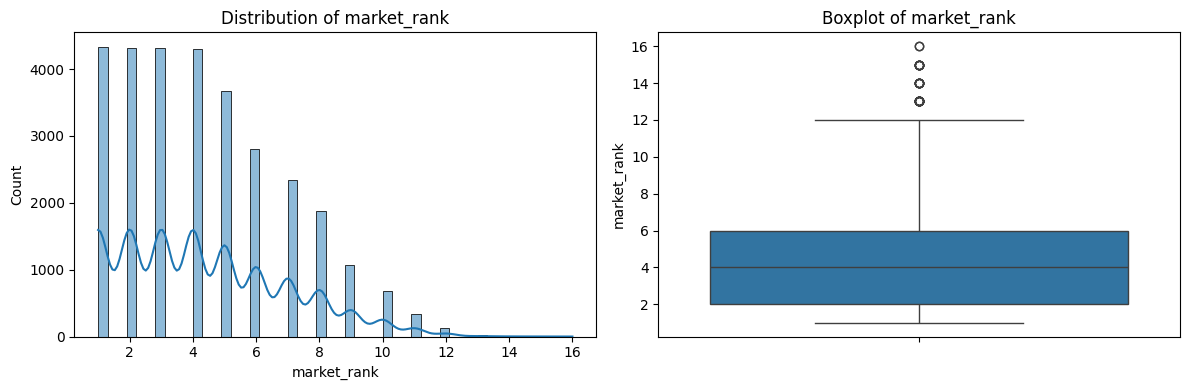

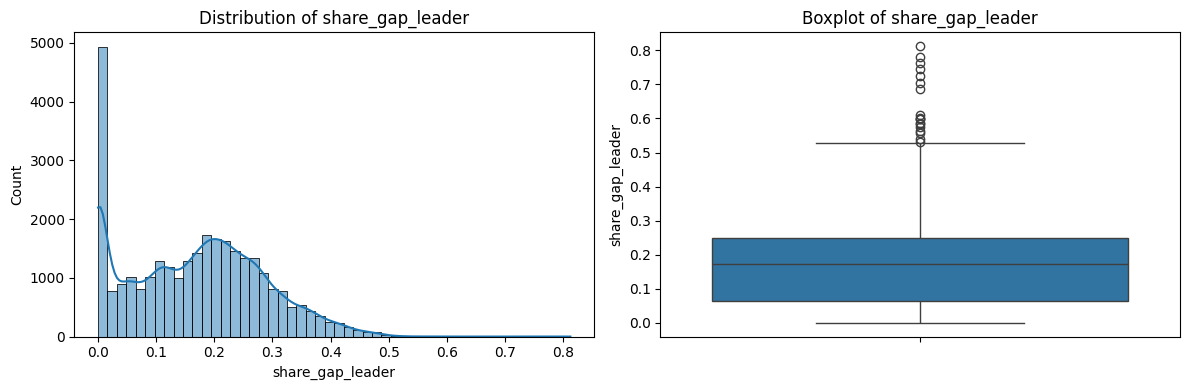

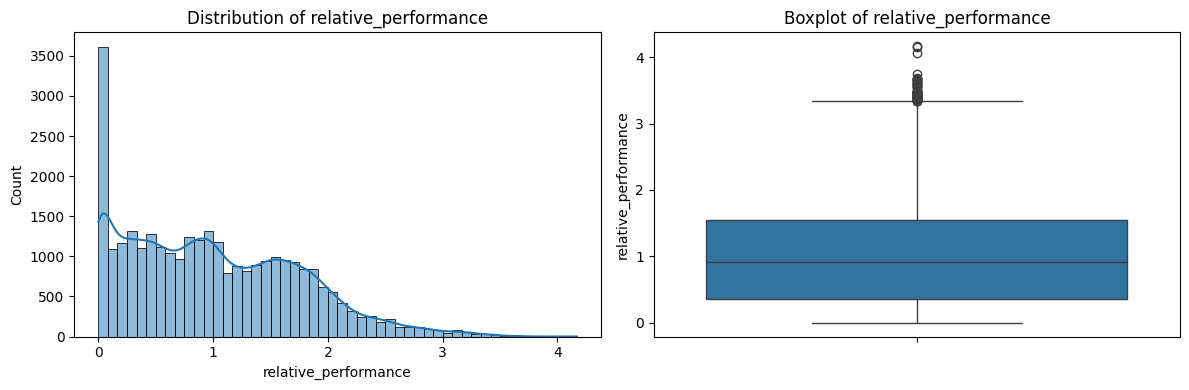

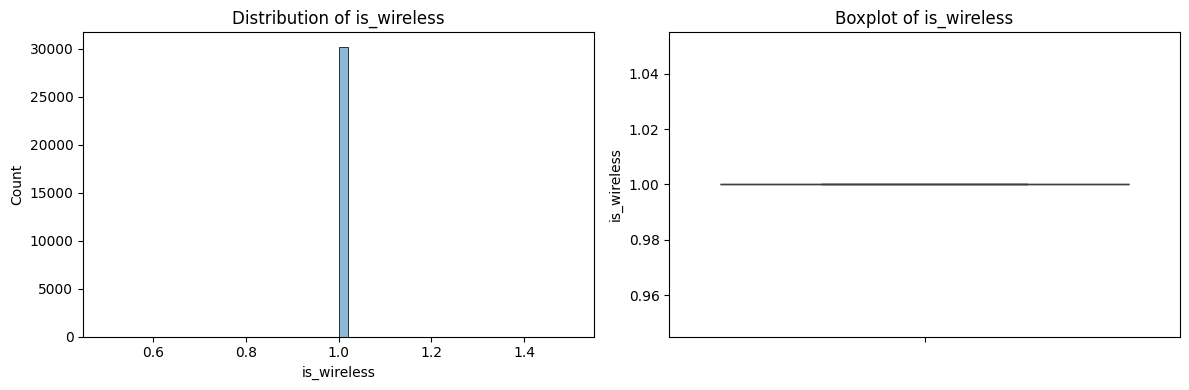

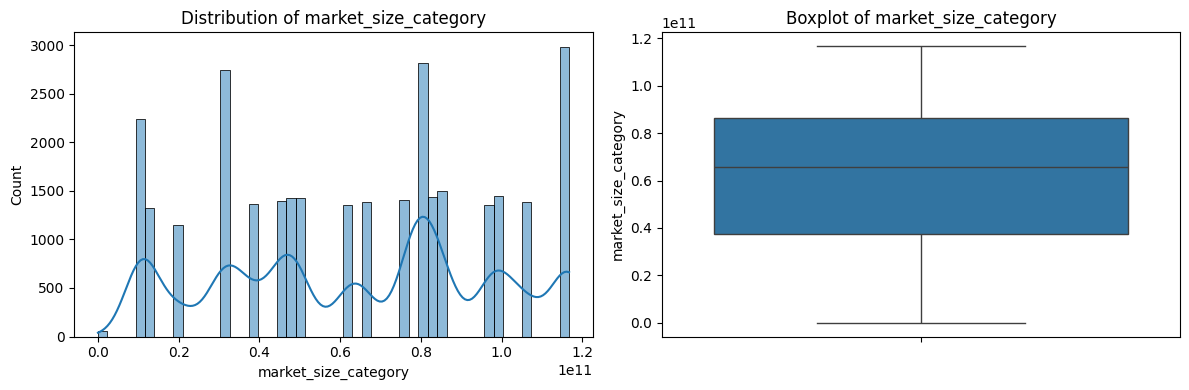

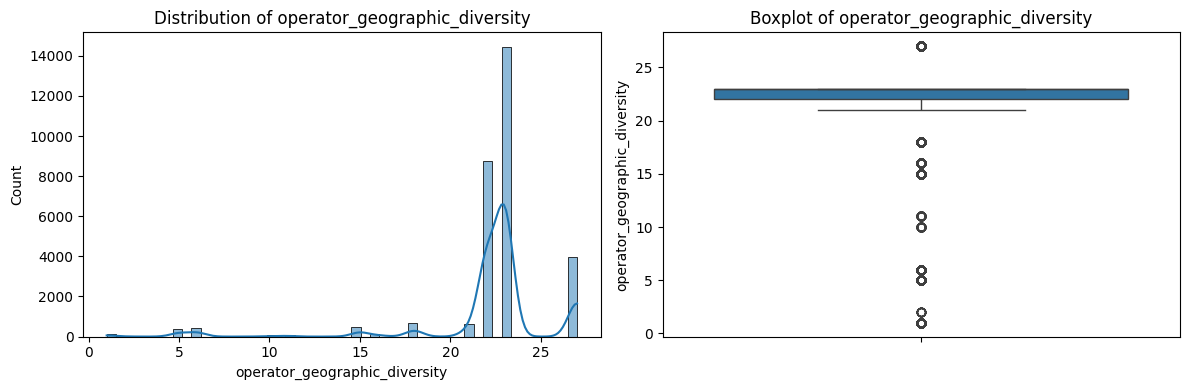

In [21]:
# -----------------------
#  Univariate Analysis
# -----------------------
for col in numeric_cols:
    plt.figure(figsize=(12,4))

    # Histogram
    plt.subplot(1,2,1)
    sns.histplot(df[col], bins=50, kde=True)
    plt.title(f'Distribution of {col}')

    # Boxplot
    plt.subplot(1,2,2)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')

    plt.tight_layout()
    plt.show()


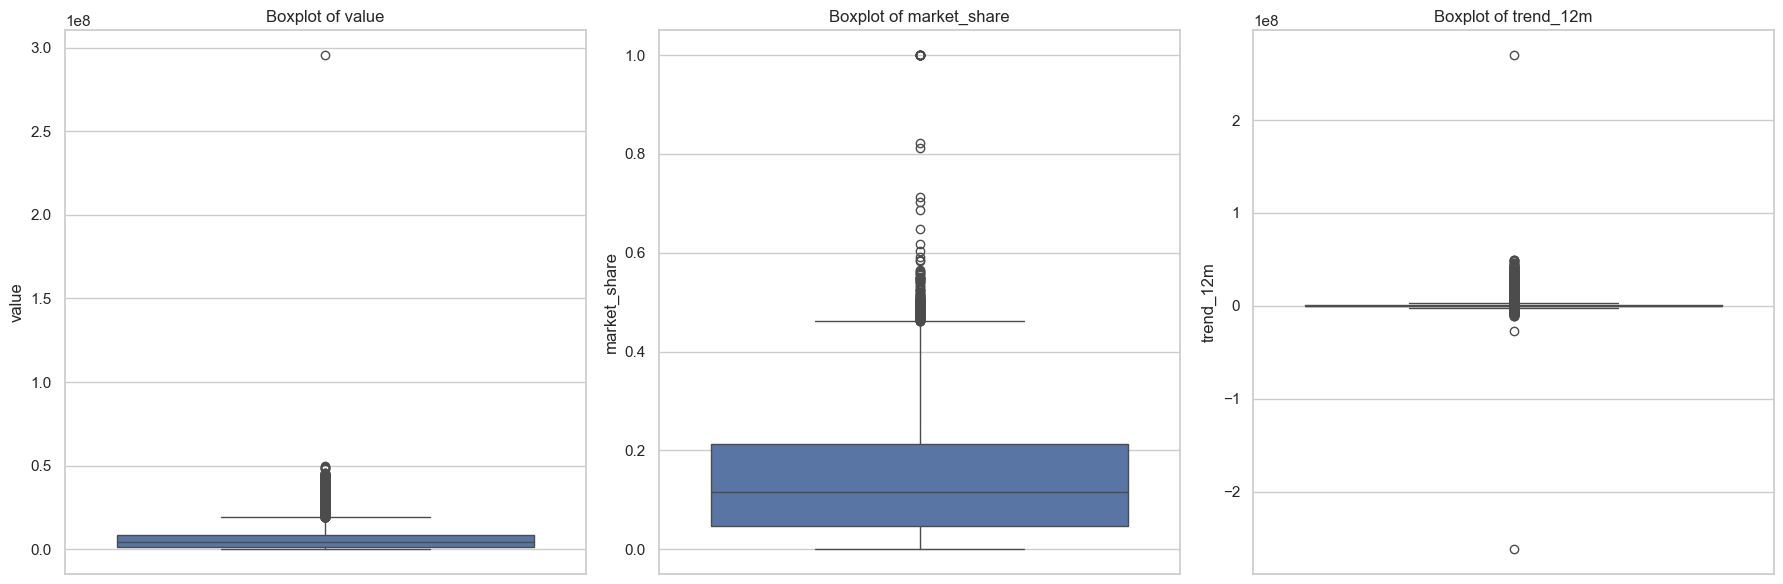

In [22]:
# Set style
sns.set(style="whitegrid")

# Columns to plot
cols_to_plot = ['value', 'market_share', 'trend_12m']

# Create subplots
plt.figure(figsize=(18, 6))

for i, col in enumerate(cols_to_plot, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

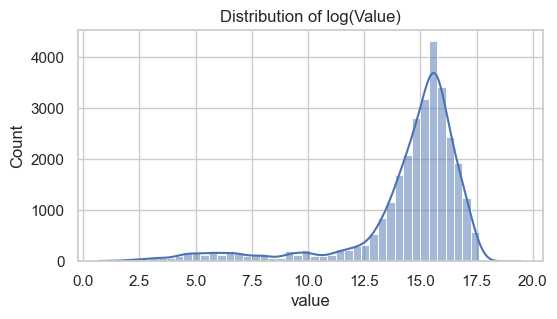

In [23]:
# For heavily skewed columns like 'value', use log scale
plt.figure(figsize=(6,3))
sns.histplot(np.log1p(df['value']), bins=50, kde=True)
plt.title('Distribution of log(Value)')
plt.show()

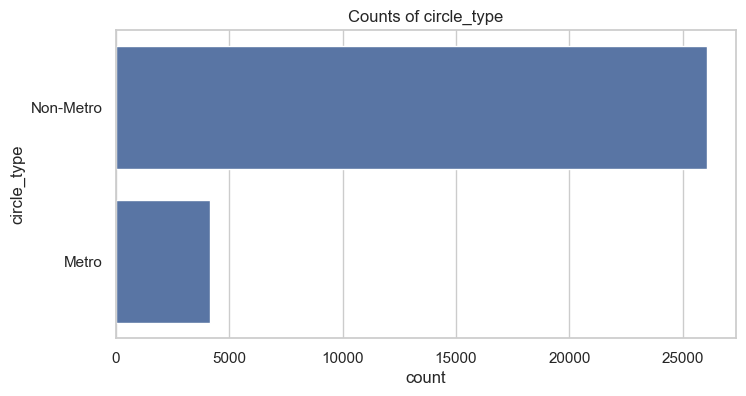

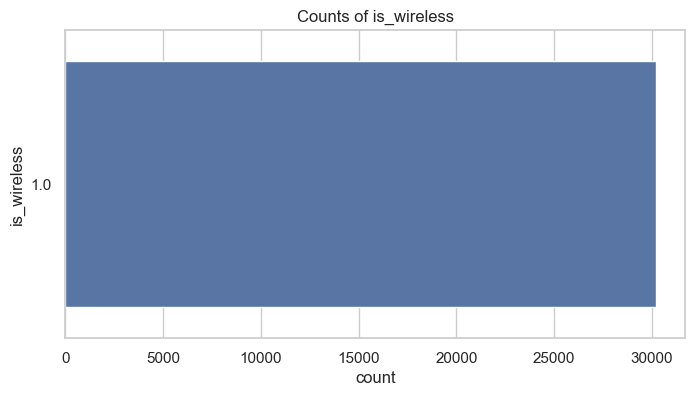

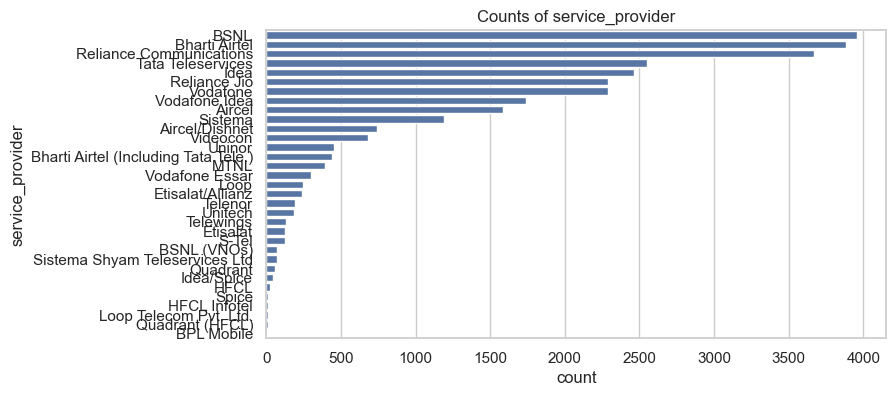

In [24]:
# -----------------------
# Categorical Columns Analysis
# -----------------------
categorical_cols = ['circle_type', 'is_wireless', 'service_provider']

for col in categorical_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(y=col, data=df, order=df[col].value_counts().index)
    plt.title(f'Counts of {col}')
    plt.show()

In [25]:
# Unique counts
print("\nUnique values:")
for col in categorical_cols:
    print(f"{col}: {df[col].nunique()}")


Unique values:
circle_type: 2
is_wireless: 1
service_provider: 33


In [26]:

# -----------------------------
# TIME-BASED ANALYSIS (TOP PROVIDERS)
# -----------------------------

Top 10 providers: ['Bharti Airtel', 'Reliance Jio', 'Vodafone Idea', 'BSNL', 'Vodafone', 'Idea', 'Reliance Communications', 'Bharti Airtel (Including Tata Tele.)', 'Tata Teleservices', 'Aircel']


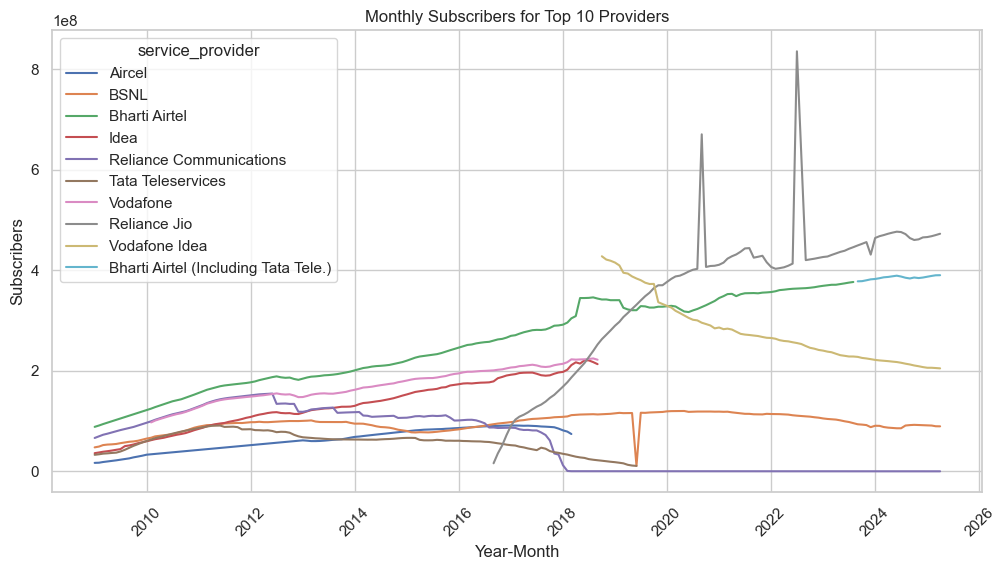

In [27]:
# Top 10 providers by total subscribers

# Step 1: Create proper datetime column for time-series order
df['year_month'] = pd.to_datetime(df['year'].astype(str) + '-' + df['month_num'].astype(str) + '-01')

# Step 2: Find top 5 providers
top_10_providers = df.groupby('service_provider')['value'].sum().sort_values(ascending=False).head(10).index.tolist()
print("Top 10 providers:", top_10_providers)

# Step 3: Filter to only those top 5 providers
df_top10 = df[df['service_provider'].isin(top_10_providers)]

# Step 4: Aggregate total subscribers per provider per month
df_agg = df_top10.groupby(['year_month', 'service_provider'])['value'].sum().reset_index()

# Step 5: Plot
plt.figure(figsize=(12,6))
sns.lineplot(data=df_agg, x='year_month', y='value', hue='service_provider')
plt.title('Monthly Subscribers for Top 10 Providers')
plt.xlabel('Year-Month')
plt.ylabel('Subscribers')
plt.xticks(rotation=45)
plt.show()


Top 5 providers: ['Bharti Airtel', 'Reliance Jio', 'Vodafone Idea', 'BSNL', 'Vodafone']


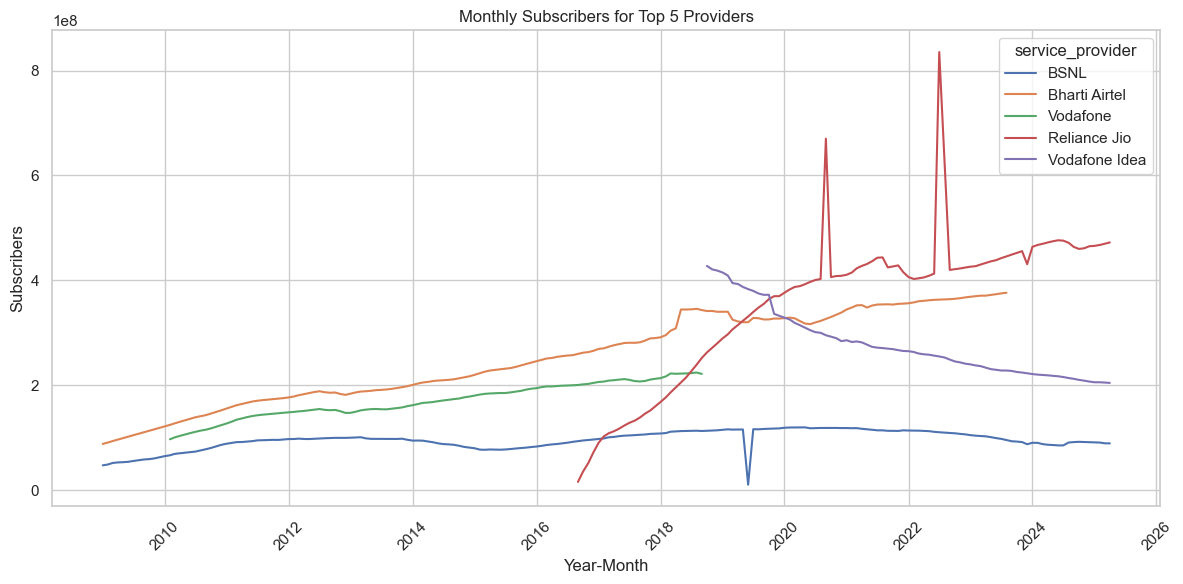

In [28]:
# Top 15 providers by total subscribers

# Step 1: Create proper datetime column for time-series order
df['year_month'] = pd.to_datetime(df['year'].astype(str) + '-' + df['month_num'].astype(str) + '-01')

# Step 2: Find top 5 providers
top_5_providers = df.groupby('service_provider')['value'].sum().sort_values(ascending=False).head(5).index.tolist()
print("Top 5 providers:", top_5_providers)

# Step 3: Filter to only those top 5 providers
df_top5 = df[df['service_provider'].isin(top_5_providers)]

# Step 4: Aggregate total subscribers per provider per month
df_agg = df_top5.groupby(['year_month', 'service_provider'])['value'].sum().reset_index()

# Step 5: Plot
plt.figure(figsize=(12,6))
sns.lineplot(data=df_agg, x='year_month', y='value', hue='service_provider')
plt.title('Monthly Subscribers for Top 5 Providers')
plt.xlabel('Year-Month')
plt.ylabel('Subscribers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


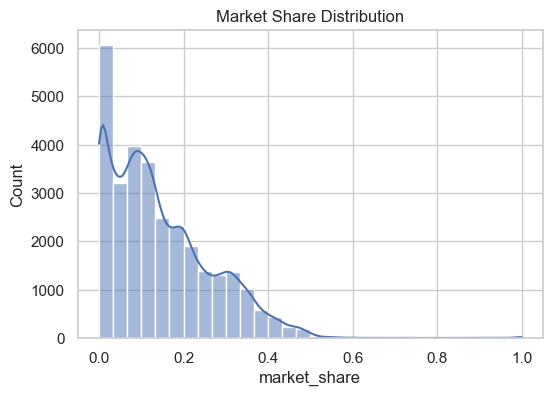

In [29]:
# Market share distribution

plt.figure(figsize=(6,4))
sns.histplot(df['market_share'], bins=30, kde=True)
plt.title('Market Share Distribution')
plt.show()

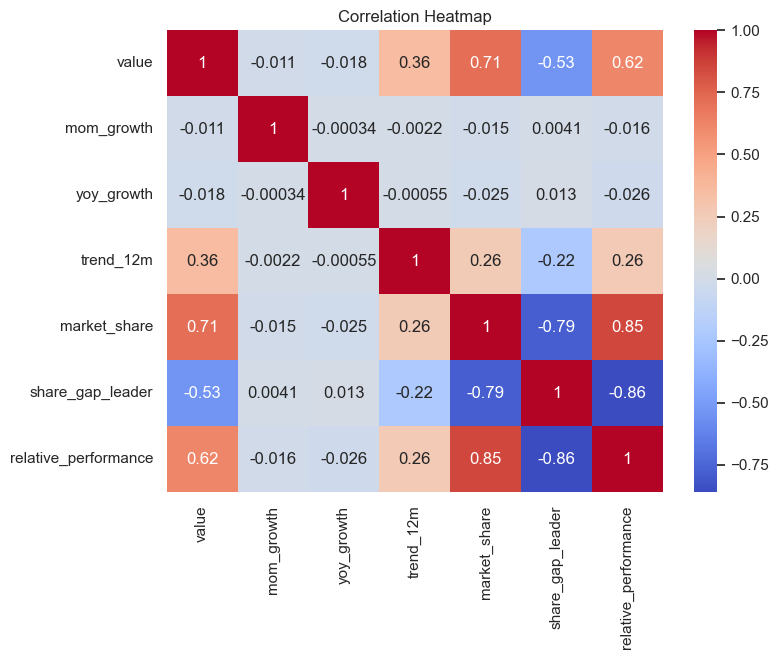

In [30]:

# -----------------------------
#  CORRELATION ANALYSIS
# -----------------------------

# Correlation heatmap
key_feats = ['value', 'mom_growth', 'yoy_growth', 'trend_12m',
             'market_share', 'share_gap_leader', 'relative_performance']

plt.figure(figsize=(8,6))
sns.heatmap(df[key_feats].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [31]:
# Print top correlated pairs
corr_matrix = df[key_feats].corr().abs().unstack().sort_values(ascending=False)
corr_pairs = corr_matrix[(corr_matrix < 1)].head(5)
print("\nTop correlated feature pairs:\n", corr_pairs)


Top correlated feature pairs:
 relative_performance  share_gap_leader        0.860739
share_gap_leader      relative_performance    0.860739
relative_performance  market_share            0.849005
market_share          relative_performance    0.849005
share_gap_leader      market_share            0.787434
dtype: float64


/var/folders/xy/l03s4lfj0x5fgxwjnvv3l1j80000gn/T/ipykernel_5943/2422550352.py:8: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='service_provider', y='value', hue='circle_type',


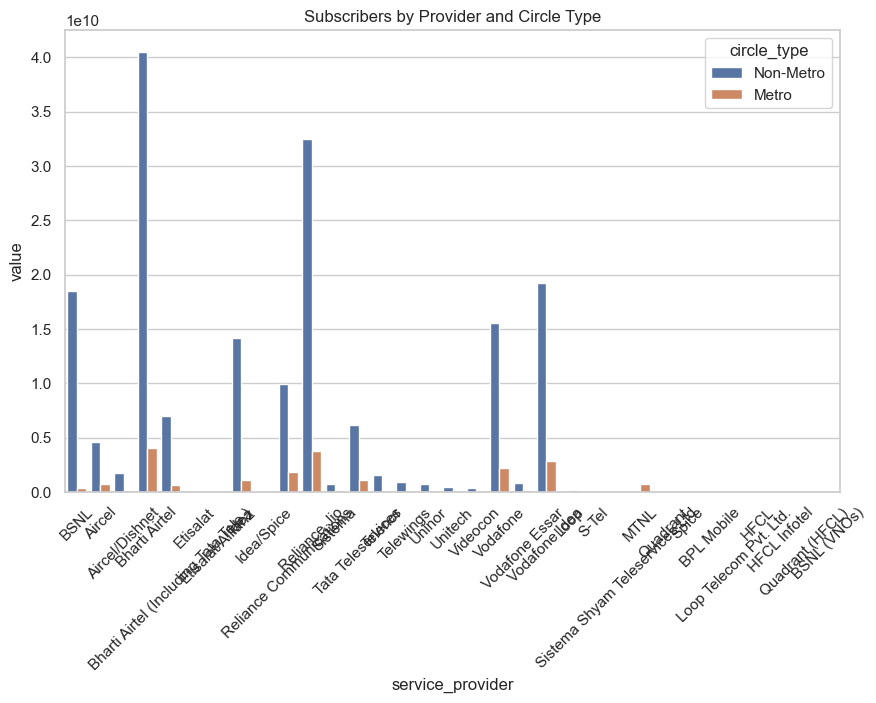

In [32]:
# -----------------------------
# BIVARIATE ANALYSIS
# -----------------------------


# Provider vs Circle Type
plt.figure(figsize=(10,6))
sns.barplot(data=df, x='service_provider', y='value', hue='circle_type',
            estimator='sum', ci=None)
plt.title('Subscribers by Provider and Circle Type')
plt.xticks(rotation=45)
plt.show()


In [33]:
# -----------------------------
#  CHURN TREND ANALYSIS
# -----------------------------


# Identify negative growth circles
neg_growth = df[df['mom_growth'] < 0].groupby('circle')['mom_growth'].mean().sort_values()
print("\nCircles with negative average MoM growth:\n", neg_growth.head(10))


Circles with negative average MoM growth:
 circle
Tamil Nadu         -0.125708
Haryana            -0.064901
Himachal Pradesh   -0.062972
Kerala             -0.056527
Gujarat            -0.051443
Madhya Pradesh     -0.048626
West Bengal        -0.046673
Delhi              -0.045839
Bihar              -0.045086
Mumbai             -0.044782
Name: mom_growth, dtype: float64


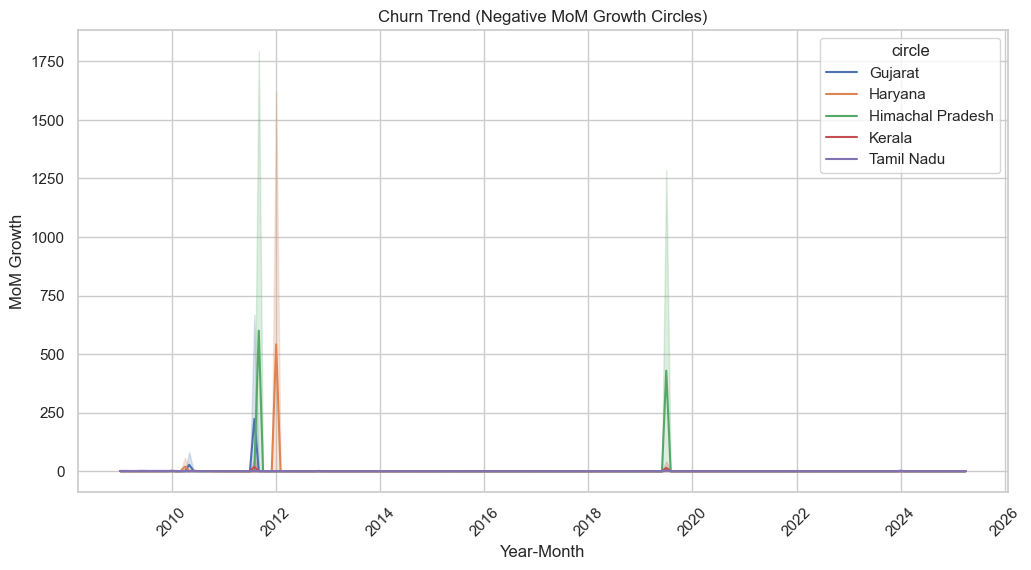

In [34]:
# Top 5 churn circles
top_churn_circles = neg_growth.head(5).index.tolist()

# Filter for churn trend visualization
df_churn = df[df['circle'].isin(top_churn_circles)]

plt.figure(figsize=(12,6))
sns.lineplot(data=df_churn, x='year_month', y='mom_growth', hue='circle')
plt.title('Churn Trend (Negative MoM Growth Circles)')
plt.xlabel('Year-Month')
plt.ylabel('MoM Growth')
plt.xticks(rotation=45)
plt.show()

/var/folders/xy/l03s4lfj0x5fgxwjnvv3l1j80000gn/T/ipykernel_5943/3095494205.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mom_circle.index, y=mom_circle.values, palette=colors)


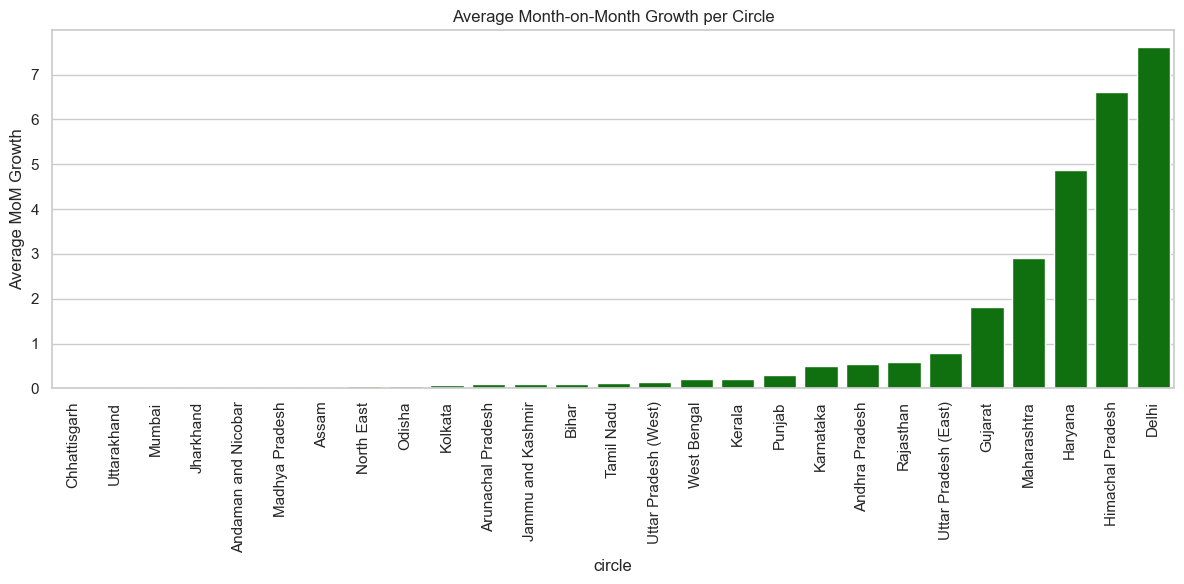

In [35]:
# Compute average MoM growth per circle
mom_circle = df.groupby('circle')['mom_growth'].mean().sort_values()

# Color: red if negative, green if positive
colors = ['red' if x < 0 else 'green' for x in mom_circle]

# Plot
plt.figure(figsize=(12,6))
sns.barplot(x=mom_circle.index, y=mom_circle.values, palette=colors)
plt.xticks(rotation=90)
plt.ylabel('Average MoM Growth')
plt.title('Average Month-on-Month Growth per Circle')
plt.tight_layout()
plt.show()

/var/folders/xy/l03s4lfj0x5fgxwjnvv3l1j80000gn/T/ipykernel_5943/1580442295.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_negative.values, y=top_negative.index, palette='Reds_r')


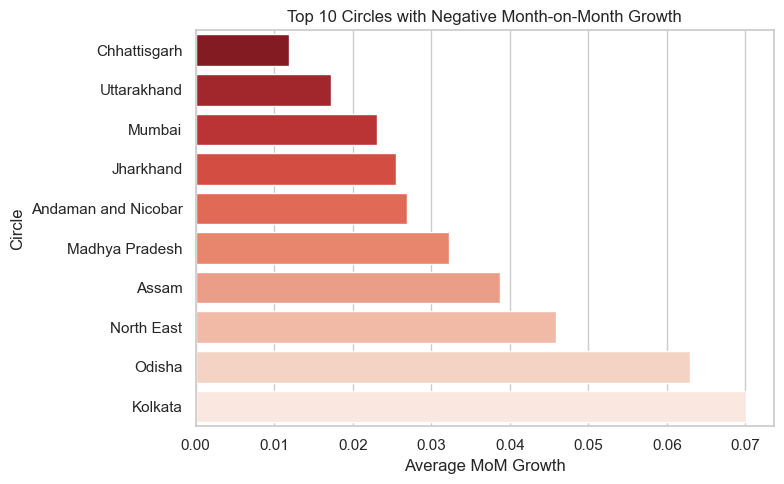

In [36]:
# Top 10 circles with negative average MoM growth
top_negative = mom_circle.nsmallest(10)

plt.figure(figsize=(8,5))
sns.barplot(x=top_negative.values, y=top_negative.index, palette='Reds_r')
plt.xlabel('Average MoM Growth')
plt.ylabel('Circle')
plt.title('Top 10 Circles with Negative Month-on-Month Growth')
plt.tight_layout()
plt.show()


In [37]:
# Key Insights
# -----------------------
# Top providers by subscribers
top_ops = df.groupby('service_provider')['value'].sum().sort_values(ascending=False).head(10)
print("\nTop 10 Providers by Total Subscribers:\n", top_ops)

# Metro vs Non-Metro analysis
metro_summary = df.groupby('circle_type')['value'].sum()
print("\nTotal subscribers Metro vs Non-Metro:\n", metro_summary)

# Negative growth circles
neg_growth = df[df['mom_growth'] < 0].groupby('circle')['mom_growth'].mean().sort_values()
print("\nCircles with negative average MoM growth:\n", neg_growth.head(10))


Top 10 Providers by Total Subscribers:
 service_provider
Bharti Airtel                           4.448258e+10
Reliance Jio                            3.626207e+10
Vodafone Idea                           2.201273e+10
BSNL                                    1.880140e+10
Vodafone                                1.775930e+10
Idea                                    1.529843e+10
Reliance Communications                 1.181269e+10
Bharti Airtel (Including Tata Tele.)    7.699103e+09
Tata Teleservices                       7.310867e+09
Aircel                                  5.307474e+09
Name: value, dtype: float64

Total subscribers Metro vs Non-Metro:
 circle_type
Metro        2.026674e+10
Non-Metro    1.758159e+11
Name: value, dtype: float64

Circles with negative average MoM growth:
 circle
Tamil Nadu         -0.125708
Haryana            -0.064901
Himachal Pradesh   -0.062972
Kerala             -0.056527
Gujarat            -0.051443
Madhya Pradesh     -0.048626
West Bengal        -0.04667

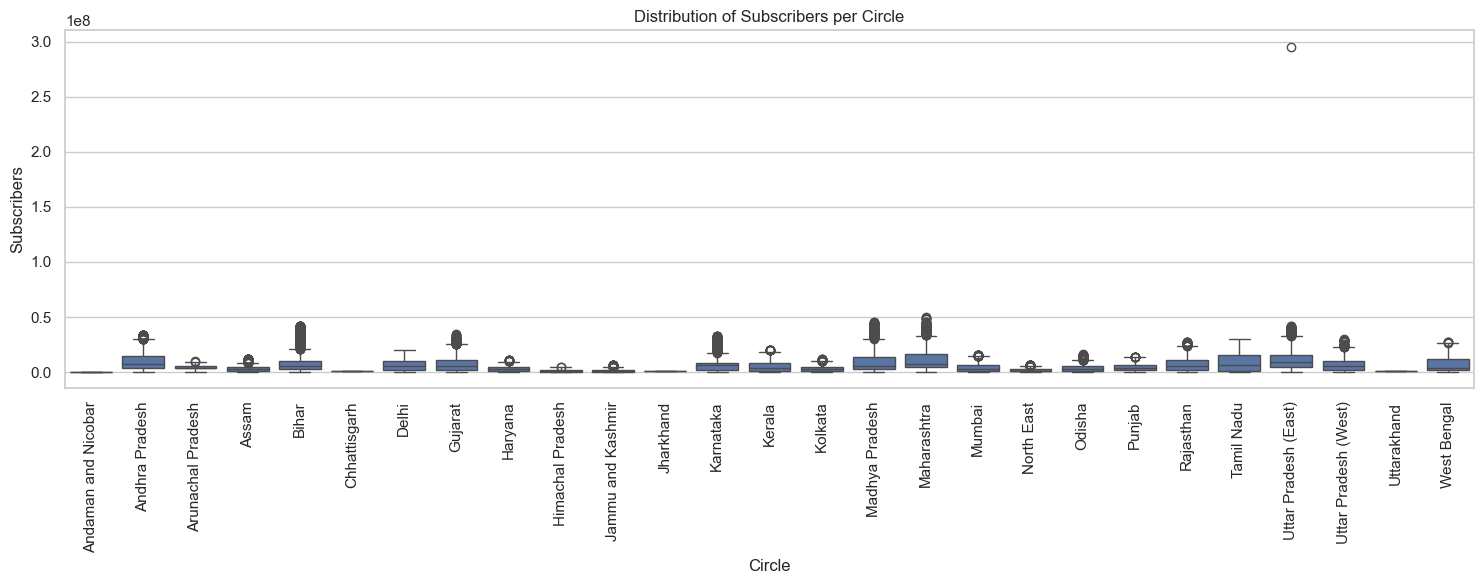

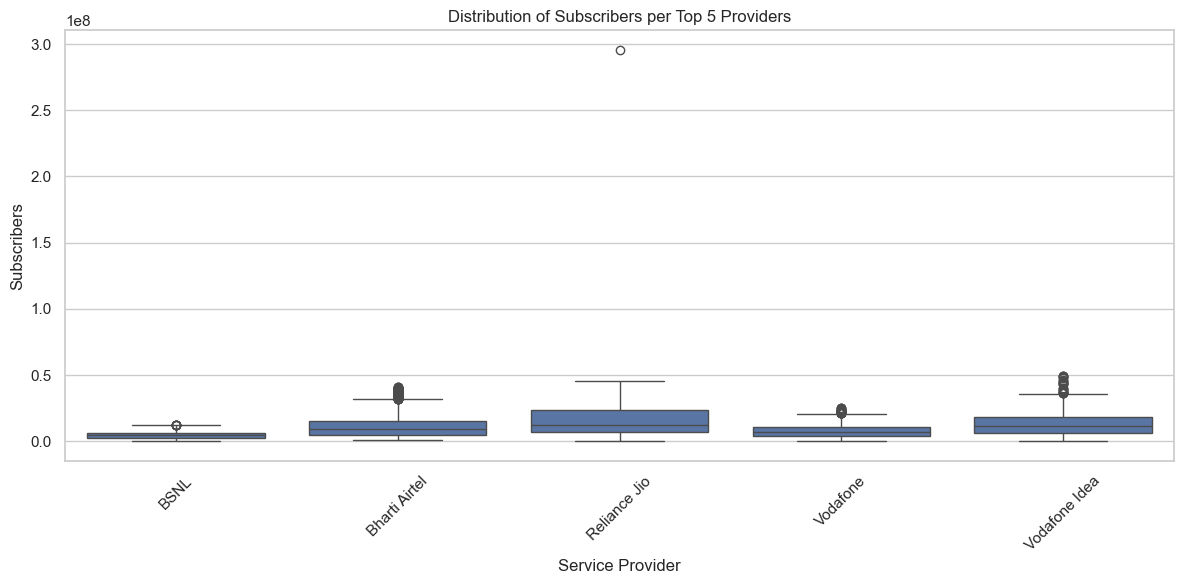

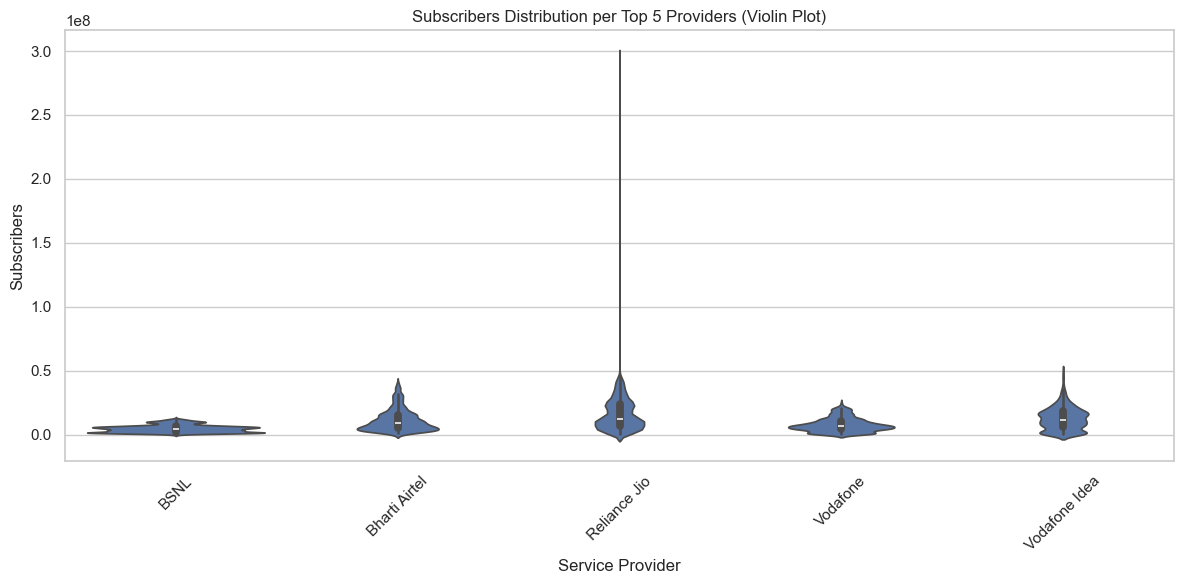

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# Make sure top 5 providers list exists
top_5_providers = df.groupby('service_provider')['value'].sum().sort_values(ascending=False).head(5).index.tolist()

# -------------------------------
# 1️⃣ Boxplot per Circle
# -------------------------------
plt.figure(figsize=(15,6))
sns.boxplot(data=df, x='circle', y='value')
plt.xticks(rotation=90)
plt.title('Distribution of Subscribers per Circle')
plt.xlabel('Circle')
plt.ylabel('Subscribers')
plt.tight_layout()
plt.savefig('boxplot_circle.png')  # Save figure for slides
plt.show()

# -------------------------------
# 2️⃣ Boxplot per Top Providers
# -------------------------------
plt.figure(figsize=(12,6))
sns.boxplot(data=df[df['service_provider'].isin(top_5_providers)],
            x='service_provider', y='value')
plt.xticks(rotation=45)
plt.title('Distribution of Subscribers per Top 5 Providers')
plt.xlabel('Service Provider')
plt.ylabel('Subscribers')
plt.tight_layout()
plt.savefig('boxplot_top5_providers.png')
plt.show()

# -------------------------------
# 3️⃣ Violin Plot per Top Providers
# -------------------------------
plt.figure(figsize=(12,6))
sns.violinplot(data=df[df['service_provider'].isin(top_5_providers)],
               x='service_provider', y='value')
plt.xticks(rotation=45)
plt.title('Subscribers Distribution per Top 5 Providers (Violin Plot)')
plt.xlabel('Service Provider')
plt.ylabel('Subscribers')
plt.tight_layout()
plt.savefig('violin_top5_providers.png')
plt.show()


In [39]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
try:
    from IPython.display import display
except ImportError:
    display = print


In [40]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
import os
paths = ["Cleaned_Telecom_Subscriptions.csv", "notebooks/Cleaned_Telecom_Subscriptions.csv", "../data/Cleaned_Telecom_Subscriptions.csv", "data/Cleaned_Telecom_Subscriptions.csv"]
for path in paths:
    if os.path.exists(path):
        data = pd.read_csv(path)
        break


/var/folders/xy/l03s4lfj0x5fgxwjnvv3l1j80000gn/T/ipykernel_5943/2883365651.py:5: DtypeWarning: Columns (0: value) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(path)


In [42]:
print("Dataset shape:", data.shape)
display(data.head())

Dataset shape: (70728, 8)


,year,month,circle,type_of_connection,service_provider,value,unit,notes
0,2025,April,Andhra Pradesh,wireless,Bharti Airtel (Including Tata Tele.),33965795,value in absolute number,NaN
1,2025,April,Assam,wireless,Bharti Airtel (Including Tata Tele.),12314102,value in absolute number,NaN
2,2025,April,Bihar,wireless,Bharti Airtel (Including Tata Tele.),40967773,value in absolute number,NaN
3,2025,April,Delhi,wireless,Bharti Airtel (Including Tata Tele.),18877637,value in absolute number,NaN
4,2025,April,Gujarat,wireless,Bharti Airtel (Including Tata Tele.),12401101,value in absolute number,NaN


In [43]:
cat_cols = data.select_dtypes(include=['object']).columns

le = LabelEncoder()
for col in cat_cols:
    data[col] = le.fit_transform(data[col].astype(str))

print("\nMissing values per column:")
print(data.isnull().sum())

data.fillna(data.median(), inplace=True)


Missing values per column:
year                  0
month                 0
circle                0
type_of_connection    0
service_provider      0
value                 0
unit                  0
notes                 0
dtype: int64


/var/folders/xy/l03s4lfj0x5fgxwjnvv3l1j80000gn/T/ipykernel_5943/3949987663.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = data.select_dtypes(include=['object']).columns


,year,month,circle,type_of_connection,service_provider,value,unit,notes
0,2025,0,4,0,7,25174,0,69
1,2025,0,6,0,7,4575,0,69
2,2025,0,7,0,7,28857,0,69
3,2025,0,11,0,7,13493,0,69
4,2025,0,12,0,7,4761,0,69
...,...,...,...,...,...,...,...,...
70723,2009,4,33,1,4,7683,0,69
70724,2009,4,34,1,4,46273,0,69
70725,2009,4,36,1,4,22808,0,69
70726,2009,4,37,1,4,842,0,69


In [44]:
target_col = 'circle'  
if target_col not in data.columns:
    raise ValueError(f"The column '{target_col}' is not found. Please update 'target_col' to your target variable name.")

X = data.drop(columns=[target_col])
y = data[target_col]

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [46]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [47]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [48]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

In [49]:
plt.figure(figsize=(5,4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

/var/folders/xy/l03s4lfj0x5fgxwjnvv3l1j80000gn/T/ipykernel_5943/3349667968.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [50]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

n_classes = len(np.unique(y_test))

plt.figure(figsize=(7, 6))

if n_classes == 2:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc_val:.2f})")

else:
    y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
    
    if y_proba.ndim == 1:  # If model returned 1D probabilities
        y_proba_bin = np.tile(y_proba.reshape(-1, 1), (1, n_classes))
    else:
        y_proba_bin = y_proba

    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba_bin[:, i])
        roc_auc_i = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc_i:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

/var/folders/xy/l03s4lfj0x5fgxwjnvv3l1j80000gn/T/ipykernel_5943/501223984.py:31: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [51]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.06      0.54      0.11      1020
           1       0.00      0.00      0.00         3
           2       0.00      0.00      0.00         3
           3       0.00      0.00      0.00        18
           4       0.06      0.02      0.03       885
           5       0.00      0.00      0.00        17
           6       0.02      0.00      0.01       824
           7       0.04      0.18      0.07       863
           9       0.06      0.18      0.09        57
          10       0.00      0.00      0.00        13
          11       0.05      0.02      0.02       940
          12       0.00      0.00      0.00       927
          13       0.05      0.10      0.07       872
          14       0.00      0.00      0.00       931
          15       0.07      0.02      0.03       838
          16       0.00      0.00      0.00        17
          17       0.03      0.00      0.01       929
   

/opt/miniconda3/envs/data_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/envs/data_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/envs/data_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

In [52]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=5),
        "KNN": KNeighborsClassifier()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"\n{name} Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))



Logistic Regression Accuracy: 0.0525
              precision    recall  f1-score   support

           0       0.06      0.54      0.11      1020
           1       0.00      0.00      0.00         3
           2       0.00      0.00      0.00         3
           3       0.00      0.00      0.00        18
           4       0.06      0.02      0.03       885
           5       0.00      0.00      0.00        17
           6       0.02      0.00      0.01       824
           7       0.04      0.18      0.07       863
           9       0.06      0.18      0.09        57
          10       0.00      0.00      0.00        13
          11       0.05      0.02      0.02       940
          12       0.00      0.00      0.00       927
          13       0.05      0.10      0.07       872
          14       0.00      0.00      0.00       931
          15       0.07      0.02      0.03       838
          16       0.00      0.00      0.00        17
          17       0.03      0.00      0.01

/opt/miniconda3/envs/data_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/envs/data_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/envs/data_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is


Random Forest Accuracy: 0.1944
              precision    recall  f1-score   support

           0       0.31      0.33      0.32      1020
           1       0.00      0.00      0.00         3
           2       0.00      0.00      0.00         3
           3       0.00      0.00      0.00        18
           4       0.20      0.20      0.20       885
           5       0.00      0.00      0.00        17
           6       0.19      0.16      0.17       824
           7       0.16      0.17      0.16       863
           8       0.00      0.00      0.00         0
           9       0.17      0.16      0.16        57
          10       0.00      0.00      0.00        13
          11       0.28      0.28      0.28       940
          12       0.17      0.18      0.17       927
          13       0.18      0.19      0.19       872
          14       0.21      0.19      0.20       931
          15       0.15      0.14      0.15       838
          16       0.00      0.00      0.00      

/opt/miniconda3/envs/data_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/envs/data_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/envs/data_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", resul


Gradient Boosting Accuracy: 0.0913
              precision    recall  f1-score   support

           0       0.06      0.30      0.10      1020
           1       0.02      1.00      0.03         3
           2       0.00      0.00      0.00         3
           3       0.00      0.00      0.00        18
           4       0.05      0.08      0.07       885
           5       0.00      0.00      0.00        17
           6       0.09      0.06      0.07       824
           7       0.00      0.00      0.00       863
           8       0.00      0.00      0.00         0
           9       0.43      0.11      0.17        57
          10       0.04      0.15      0.07        13
          11       0.10      0.20      0.13       940
          12       0.13      0.07      0.09       927
          13       0.11      0.12      0.11       872
          14       0.15      0.00      0.00       931
          15       0.08      0.11      0.10       838
          16       0.03      0.12      0.04  

/opt/miniconda3/envs/data_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/envs/data_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/envs/data_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", resul


KNN Accuracy: 0.0771
              precision    recall  f1-score   support

           0       0.12      0.31      0.17      1020
           1       0.00      0.00      0.00         3
           2       0.00      0.00      0.00         3
           3       0.00      0.00      0.00        18
           4       0.03      0.09      0.04       885
           5       0.03      0.06      0.04        17
           6       0.05      0.12      0.07       824
           7       0.04      0.08      0.05       863
           8       0.00      0.00      0.00         0
           9       0.06      0.09      0.07        57
          10       0.00      0.00      0.00        13
          11       0.10      0.17      0.13       940
          12       0.05      0.08      0.06       927
          13       0.06      0.10      0.08       872
          14       0.08      0.07      0.07       931
          15       0.06      0.05      0.05       838
          16       0.00      0.00      0.00        17
     

/opt/miniconda3/envs/data_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/envs/data_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/envs/data_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", resul

In [53]:
result_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy']).sort_values(by='Accuracy', ascending=False)
print("\nModel Comparison:\n", result_df)


Model Comparison:
                  Model  Accuracy
1        Decision Tree  0.335878
2        Random Forest  0.194448
3    Gradient Boosting  0.091286
4                  KNN  0.077054
0  Logistic Regression  0.052500


In [54]:
plt.figure(figsize=(10,5))
sns.barplot(x='Accuracy', y='Model', data=result_df, palette='viridis')
plt.title("Model Accuracy Comparison")
plt.show()

/var/folders/xy/l03s4lfj0x5fgxwjnvv3l1j80000gn/T/ipykernel_5943/2055113208.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy', y='Model', data=result_df, palette='viridis')
/var/folders/xy/l03s4lfj0x5fgxwjnvv3l1j80000gn/T/ipykernel_5943/2055113208.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [55]:
best_model_name = result_df.iloc[0]['Model']
best_model = models[best_model_name]
print(f"\n Best Model: {best_model_name} with Accuracy = {result_df.iloc[0]['Accuracy']:.4f}")


 Best Model: Decision Tree with Accuracy = 0.3359


In [56]:
import joblib
joblib.dump(best_model, f"best_model_{best_model_name.replace(' ', '_')}.pkl")
print(f"Model saved as best_model_{best_model_name.replace(' ', '_')}.pkl")

Model saved as best_model_Decision_Tree.pkl


In [57]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=5),
        "KNN": KNeighborsClassifier()
}

evaluation = []

for name, model in models.items():
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    auc = np.nan
    if hasattr(model, "predict_proba"):
        try:
            y_proba = model.predict_proba(X_test)
            if len(np.unique(y_test)) == 2:
                auc = roc_auc_score(y_test, y_proba[:, 1])
            elif len(np.unique(y_test)) > 2:
                auc = roc_auc_score(y_test, y_proba, multi_class='ovr')
        except Exception:
            auc = np.nan 

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    evaluation.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'AUC': auc
    })


In [58]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np
import pandas as pd

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=5),
        "KNN": KNeighborsClassifier()
}

evaluation = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    auc = np.nan
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)
        try:
            if len(np.unique(y_test)) == 2:
                auc = roc_auc_score(y_test, y_proba[:, 1])
            else:
                if y_proba.shape[1] == len(np.unique(y_test)):
                    auc = roc_auc_score(y_test, y_proba, multi_class='ovr')
        except ValueError:
            auc = np.nan

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    evaluation.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'AUC': auc
    })
    
eval_df = pd.DataFrame(evaluation).sort_values(by='Accuracy', ascending=False)
display(eval_df)


,Model,Accuracy,Precision,Recall,F1-Score,AUC
1,Decision Tree,0.335595,0.392967,0.335595,0.354357,NaN
2,Random Forest,0.200386,0.200399,0.200386,0.200250,NaN
3,Gradient Boosting,0.091286,0.129321,0.091286,0.080267,NaN
4,KNN,0.077054,0.095352,0.077054,0.072845,NaN
0,Logistic Regression,0.052500,0.034740,0.052500,0.025428,NaN


In [59]:
best_model_name = eval_df.iloc[0]['Model']
print("best Model Selected:", best_model_name)

best Model Selected: Decision Tree
